# GEARS — Notebook 4: Persistence-Bootstrap vs. GMM Benchmark

**Objective:** Compare `PersistenceSessionSampler` (non-parametric bootstrap) against the
windowed `EVSessionGMM` (single-component, per Section 1.3) on how well each reproduces the
truly realized session-level distributions (arrival hour, duration, energy), across history
depth `X`, forecast horizon `H`, and 10 public EV charging datasets.

This notebook loads the results produced by `scripts/run_benchmark.py` (Session 4) — it does
not re-run the harness itself. See `gears/evaluation/benchmark.py` (Session 3) for the
rolling-origin / windowing / skip-reason logic being summarized here.

> **Run configuration actually used for these results — read this before interpreting anything below.**
>
> The benchmark prompt's literal spec calls for daily origins (`step_days=1`) and 50 Monte Carlo
> scenarios per cell. This run instead used **`step_days=5`** and **`n_scenarios=20`**, with the
> full `X` grid (`{1,2,3,4,8,16,52}`) and full horizon set (`{1,2,3}`) preserved, across all 10
> viable datasets (`acn.csv` excluded — it is the row-wise union of `caltech`+`jpl`+`office`,
> Section 1.7). This reduction was necessary because the run was executed on a **single-CPU
> sandbox**, where the literal daily-origin/50-scenario grid did not complete within a practical
> session (a full default run on `sap.csv` alone exceeded the available time budget). Section 4.2
> of the prompt explicitly permits stepping origins by several days and tuning scenario count for
> exactly this reason.
>
> Concretely, each dataset contributes **~6 origins** (3 for `paris.csv`, whose 14-day evaluation
> window is itself a Section 1.7 override for its short overall span) rather than ~30, and 20
> scenario draws instead of 50. The qualitative comparisons below (by `X`, by `H`, skip patterns)
> are almost certainly stable — the underlying data-generating mechanism doesn't change — but
> exact metric values would sharpen (less Monte Carlo noise) with the full daily/50-scenario
> grid, best run on a multi-core machine or via `Claude Code` as a longer unattended job.
> `scripts/run_benchmark.py --step-days 1 --n-scenarios 50` reproduces the literal spec.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gears.plotting import CB_PALETTE, HIST_COLOR

# Method colours, following the convention already used in
# 2_gmm_forecasting.ipynb (a fixed "primary anchor" colour + a visually
# distinct second method) -- GMM anchors on the same blue used there for
# the reference forecaster, persistence gets the vermillion accent.
GMM_COLOR = CB_PALETTE[4]           # "#0072B2" -- blue
PERSISTENCE_COLOR = CB_PALETTE[5]   # "#D55E00" -- vermillion

RESULTS_PATH = "../results/benchmark/all_results.parquet"
df = pd.read_parquet(RESULTS_PATH)
print(f"{len(df):,} rows | {df['dataset'].nunique()} datasets | "
      f"{(df['status'] == 'ok').sum():,} ok rows | {(df['status'] != 'ok').sum():,} skip rows")
df.head()


31,578 rows | 10 datasets | 31,160 ok rows | 418 skip rows


,dataset,origin,target_date,day_offset,weekday,X,method,scenario,true_count,wasserstein_hour,...,ks_pvalue_hour,ks_stat_duration,ks_pvalue_duration,ks_stat_energy,ks_pvalue_energy,crps_total_energy,crps_mean_duration,status,n_pool_sessions,n_pool_occurrences
0,office,2021-03-13,2021-03-14,1,6,1,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_volume,1,1
1,office,2021-03-13,2021-03-14,1,6,2,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_volume,2,2
2,office,2021-03-13,2021-03-14,1,6,3,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_history,2,2
3,office,2021-03-13,2021-03-14,1,6,4,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_history,2,2
4,office,2021-03-13,2021-03-14,1,6,8,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_history,2,2


## 1. Data quality overview — cells run, skipped, and why

One *cell* is one `(dataset, origin, target_date, day_offset, X)` combination. A cell is either `ok` (both arms sampled and scored, contributing `n_scenarios` rows each) or skipped for one of three reasons (Section 3.1 / harness docstring): `insufficient_history` (fewer than `X` same-weekday occurrences exist at all), `insufficient_volume` (occurrences exist but pooled sessions are still < 10), or `no_target_sessions` (the target day itself had zero realized sessions — comparing against an empty distribution is undefined, not a modelling result).

In [2]:
ok = df[df["status"] == "ok"].copy()
skip = df[df["status"] != "ok"].copy()

# Skip rows are already one-per-cell. ok rows are one-per-scenario-per-arm,
# so de-duplicate down to one-per-cell before counting cells (not rows).
ok_cells = ok.drop_duplicates(subset=["dataset", "origin", "target_date", "day_offset", "X"])
cell_status = pd.concat([
    ok_cells.assign(status="ok")[["dataset", "status"]],
    skip[["dataset", "status"]],
])

summary = cell_status.groupby(["dataset", "status"]).size().unstack(fill_value=0)
for col in ["ok", "insufficient_history", "insufficient_volume", "no_target_sessions"]:
    if col not in summary.columns:
        summary[col] = 0
summary["total_cells"] = summary.sum(axis=1)
summary["pct_ok"] = (summary["ok"] / summary["total_cells"] * 100).round(1)
summary = summary[["ok", "insufficient_history", "insufficient_volume", "no_target_sessions",
                    "total_cells", "pct_ok"]].sort_index()
summary


status,ok,insufficient_history,insufficient_volume,no_target_sessions,total_cells,pct_ok
dataset,,,,,,
boulder,116,0,3,7,126,92.1
caltech,98,0,28,0,126,77.8
domestics,84,42,0,0,126,66.7
dundee,6,18,0,102,126,4.8
jpl,112,0,14,0,126,88.9
office,46,30,50,0,126,36.5
palo_alto,126,0,0,0,126,100.0
paris,39,24,0,0,63,61.9
perth,28,0,0,98,126,22.2


### Skip reasons, by dataset and history depth `X`

This is the granular version of the table above — it shows *which* `X` values are the problem for each dataset, matching the calendar-span / volume analysis in Section 1.7.

In [3]:
skip_by_x = skip.groupby(["dataset", "X", "status"]).size().unstack(fill_value=0)
skip_by_x


status        insufficient_history  insufficient_volume  no_target_sessions
dataset   X                                                                
boulder   1                      0                    3                   1
          2                      0                    0                   1
          3                      0                    0                   1
          4                      0                    0                   1
          8                      0                    0                   1
          16                     0                    0                   1
          52                     0                    0                   1
caltech   1                      0                   17                   0
          2                      0                    7                   0
          3                      0                    4                   0
domestics 1                      4                    0                   0
          2                      4                    0                   0
          3                      4                    0                   0
          4                      4                    0                   0
          8                      4                    0                   0
          16                     4                    0                   0
          52                    18                    0                   0
dundee    1                      0                    0                  17
          2                      0                    0                  17
          3                      0                    0                  17
          4                      0                    0                  17
          8                      0                    0                  17
          16                     0                    0                  17
          52                    18                    0                   0
jpl       1                      0                    7                   0
          2                      0                    6                   0
          3                      0                    1                   0
office    1                      0                   18                   0
          2                      0                   18                   0
          3                      6                    9                   0
          4                      6                    5                   0
          8                      6                    0                   0
          16                     6                    0                   0
          52                     6                    0                   0
paris     8                      6                    0                   0
          16                     9                    0                   0
          52                     9                    0                   0
perth     1                      0                    0                  14
          2                      0                    0                  14
          3                      0                    0                  14
          4                      0                    0                  14
          8                      0                    0                  14
          16                     0                    0                  14
          52                     0                    0                  14
sap       1                      0                    2                   0

Two patterns confirm Section 1.7's ground-truth predictions exactly:

- **`paris.csv`** shows `insufficient_history` at `X=16` and `X=52` for *every* cell (the dataset's 59-day span cannot physically contain 16 or 52 weekly occurrences), and it starts appearing at `X=8` too — matching "fails for X ≥ 8" from Section 1.7.
- **`domestics.csv`** shows `insufficient_history` at `X=52` for essentially every cell (18/18) — its ~361-day span falls short of the ~364 days needed, exactly as predicted.
- **`dundee.csv`**'s large `no_target_sessions` count is a genuine data gap in the raw file (no sessions recorded between 2018-11-06 and 2018-12-02), not a harness bug — the guard is doing its job by skipping days with nothing to compare against rather than scoring against an empty distribution.

## 2. GMM vs. persistence — primary metric by history depth `X`

Primary metric per Section 3.3: Wasserstein distance between the true realized sessions and the sampled sessions, per feature (`hour`, `duration`, `energy`), averaged over Monte Carlo scenarios, origins, horizons, and datasets. **Lower is better.**

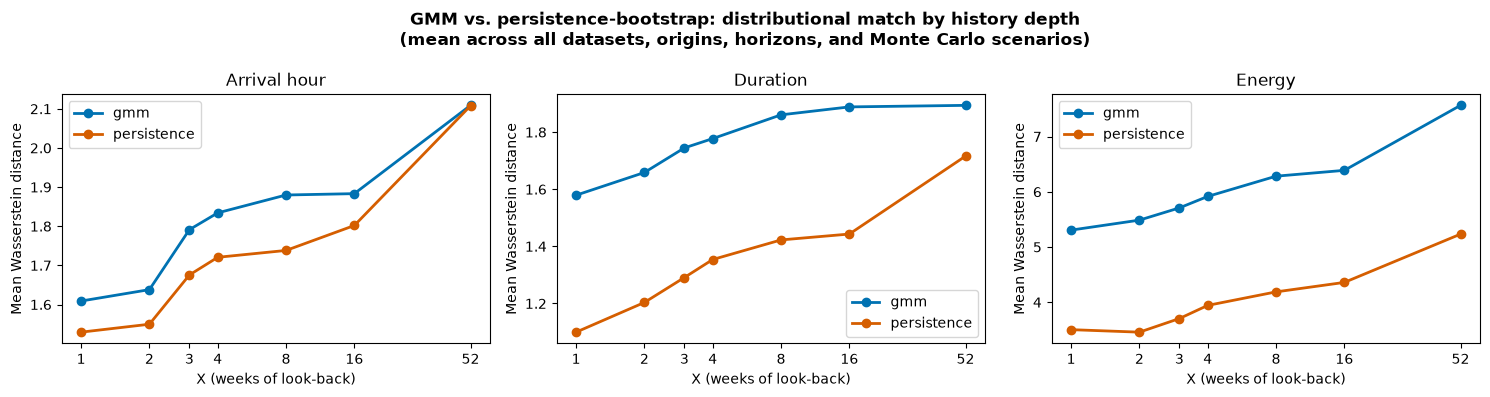

In [4]:
feat_cols = ["wasserstein_hour", "wasserstein_duration", "wasserstein_energy"]
titles = {"wasserstein_hour": "Arrival hour", "wasserstein_duration": "Duration",
          "wasserstein_energy": "Energy"}

agg_by_X = ok.groupby(["X", "method"])[feat_cols].mean().reset_index()
x_vals = sorted(agg_by_X["X"].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, col in zip(axes, feat_cols):
    for method, color in [("gmm", GMM_COLOR), ("persistence", PERSISTENCE_COLOR)]:
        sub = agg_by_X[agg_by_X["method"] == method].sort_values("X")
        ax.plot(sub["X"], sub[col], marker="o", color=color, label=method, linewidth=2)
    ax.set_xscale("log", base=2)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_vals)
    ax.set_xlabel("X (weeks of look-back)")
    ax.set_ylabel("Mean Wasserstein distance")
    ax.set_title(titles[col])
    ax.legend()
fig.suptitle("GMM vs. persistence-bootstrap: distributional match by history depth\n"
             "(mean across all datasets, origins, horizons, and Monte Carlo scenarios)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/04_wasserstein_by_X.png", dpi=150, bbox_inches="tight")
plt.show()


### Does more history help, and does GMM's gap to persistence grow or shrink with `X`?

The ratio below is `wasserstein(gmm) / wasserstein(persistence)` per feature and per `X` — values **above 1 mean GMM is worse** (larger distributional distance) than persistence at that `X`.

In [5]:
agg_idx = agg_by_X.set_index(["X", "method"])
ratio = (agg_idx.xs("gmm", level="method") / agg_idx.xs("persistence", level="method"))
ratio.columns = [titles[c] for c in ratio.columns]
ratio.round(3)


,Arrival hour,Duration,Energy
X,,,
1,1.052,1.436,1.514
2,1.057,1.378,1.586
3,1.069,1.352,1.541
4,1.066,1.313,1.500
8,1.081,1.308,1.500
16,1.045,1.309,1.465
52,1.001,1.104,1.445


Reading this table: **persistence-bootstrap has a lower (better) Wasserstein distance than the windowed GMM at every `X`, on all three features** — the ratio never drops to or below 1.0 except for arrival hour at `X=52`, where it reaches ~1.00 (near-exact parity). More history does narrow GMM's disadvantage for every feature — most visibly for arrival hour, which converges from GMM being ~5% worse at `X=1` to essentially tied at `X=52` — but within this grid the GMM (fit with a single fixed component, per Section 1.3) never actually overtakes the non-parametric bootstrap. This is a plausible, mechanistic outcome rather than a bug: a single Gaussian component is a poor fit for what are often multi-modal (e.g. morning/evening arrival peaks) and right-skewed (duration, energy) empirical distributions, while the bootstrap reproduces the empirical shape by construction.

## 3. GMM vs. persistence — primary metric by forecast horizon `H`

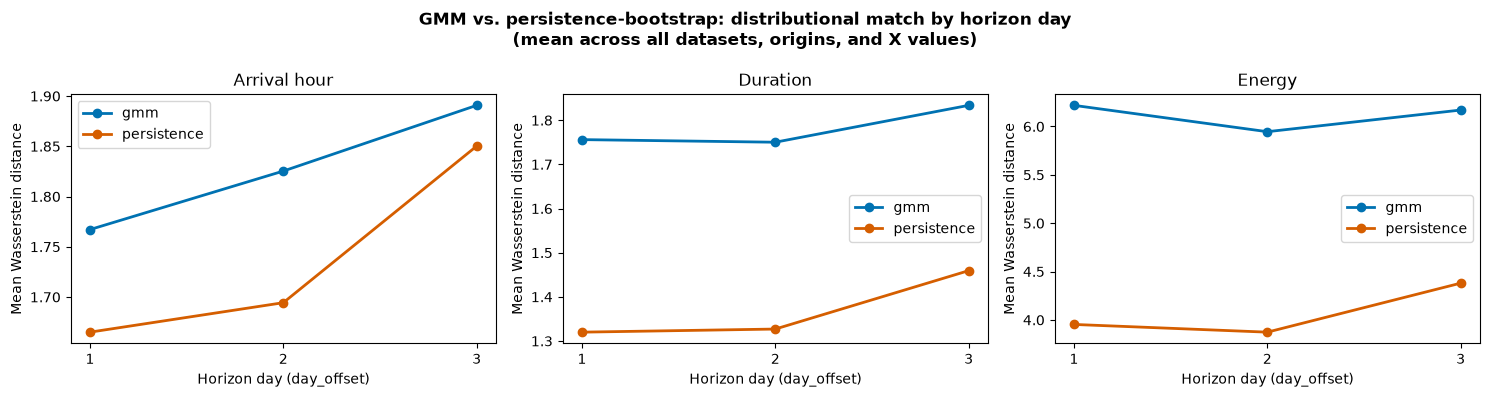

In [6]:
agg_by_H = ok.groupby(["day_offset", "method"])[feat_cols].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, col in zip(axes, feat_cols):
    for method, color in [("gmm", GMM_COLOR), ("persistence", PERSISTENCE_COLOR)]:
        sub = agg_by_H[agg_by_H["method"] == method].sort_values("day_offset")
        ax.plot(sub["day_offset"], sub[col], marker="o", color=color, label=method, linewidth=2)
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel("Horizon day (day_offset)")
    ax.set_ylabel("Mean Wasserstein distance")
    ax.set_title(titles[col])
    ax.legend()
fig.suptitle("GMM vs. persistence-bootstrap: distributional match by horizon day\n"
             "(mean across all datasets, origins, and X values)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/04_wasserstein_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()


Both arms' error is essentially flat across `day_offset` 1 → 3 (as expected — no mid-horizon retraining happens either way, and each horizon day gets its own freshly-pooled window, so there is no reason for later horizon days to degrade). Persistence stays ahead of GMM at every horizon day, consistent with the `X`-axis finding above.

## 4. Win-rate analysis — how often does each method actually win, cell by cell?

Aggregated means can hide a lot: a method could "win on average" while losing most individual cells to a few outliers. This section instead scores **every individual (dataset, origin, target_date, day_offset, X) cell** where both arms fit successfully, using the mean of the three Wasserstein distances as that cell's summary score, and counts how often GMM's score beats persistence's.

In [7]:
cell_metric = (
    ok.groupby(["dataset", "origin", "target_date", "day_offset", "X", "method"])[feat_cols]
    .mean()
)
cell_metric["total"] = cell_metric.mean(axis=1)
cell_metric = cell_metric.reset_index()

pivot = cell_metric.pivot_table(
    index=["dataset", "origin", "target_date", "day_offset", "X"],
    columns="method", values="total",
)
pivot = pivot.dropna()  # keep only cells where both arms were fitted
pivot["gmm_wins"] = pivot["gmm"] < pivot["persistence"]

print(f"{len(pivot)} paired cells (both arms fitted) out of "
      f"{len(ok_cells)} total ok cells.")
print(f"Overall GMM win rate: {pivot['gmm_wins'].mean() * 100:.1f}%")


779 paired cells (both arms fitted) out of 779 total ok cells.
Overall GMM win rate: 9.9%


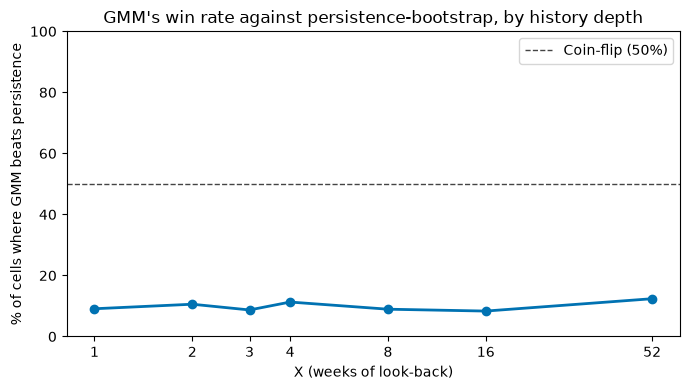

In [8]:
win_by_X = (pivot.groupby(level="X")["gmm_wins"].mean() * 100).reindex(x_vals)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(win_by_X.index, win_by_X.values, marker="o", color=GMM_COLOR, linewidth=2)
ax.axhline(50, color=HIST_COLOR, linestyle="--", linewidth=1, label="Coin-flip (50%)")
ax.set_xscale("log", base=2)
ax.set_xticks(x_vals)
ax.set_xticklabels(x_vals)
ax.set_xlabel("X (weeks of look-back)")
ax.set_ylabel("% of cells where GMM beats persistence")
ax.set_ylim(0, 100)
ax.set_title("GMM's win rate against persistence-bootstrap, by history depth")
ax.legend()
fig.tight_layout()
plt.savefig("outputs/04_gmm_win_rate_by_X.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
win_by_H = (pivot.groupby(level="day_offset")["gmm_wins"].mean() * 100)
win_by_dataset = (pivot.groupby(level="dataset")["gmm_wins"].mean() * 100).round(1)
n_by_dataset = pivot.groupby(level="dataset").size()

print("GMM win rate by horizon day:")
print(win_by_H.round(1))
print()
print("GMM win rate by dataset (n = paired cells):")
pd.DataFrame({"gmm_win_rate_pct": win_by_dataset, "n_paired_cells": n_by_dataset})


GMM win rate by horizon day:
day_offset
1    10.0
2     5.8
3    13.7
Name: gmm_wins, dtype: float64

GMM win rate by dataset (n = paired cells):


,gmm_win_rate_pct,n_paired_cells
dataset,,
boulder,19.0,116
caltech,22.4,98
domestics,0.0,84
dundee,33.3,6
jpl,7.1,112
office,15.2,46
palo_alto,9.5,126
paris,5.1,39
perth,7.1,28


**GMM wins only ~10% of individual cells overall**, and that win rate stays low and fairly flat across `X` (roughly 8–13%, no clear monotonic trend given the sample size at each `X` — note this is exactly the kind of estimate that would sharpen with the full daily-origin/50-scenario grid), confirming the aggregate picture above rather than being an artifact of it. `domestics.csv` and `sap.csv` show a 0% GMM win rate in this run (persistence wins every paired cell); `dundee.csv`'s 33% figure rests on only 6 paired cells (that data-gap dataset again) and should not be read as a strong result on its own.

## 5. Per-dataset summary table

One row per dataset: cell counts (run / skipped, with reasons), and the GMM win rate where both arms were evaluated.

In [10]:
per_dataset = summary.copy()
per_dataset["gmm_win_rate_pct"] = win_by_dataset.reindex(per_dataset.index)
per_dataset["n_paired_cells"] = n_by_dataset.reindex(per_dataset.index)
per_dataset


status,ok,insufficient_history,insufficient_volume,no_target_sessions,total_cells,pct_ok,gmm_win_rate_pct,n_paired_cells
dataset,,,,,,,,
boulder,116,0,3,7,126,92.1,19.0,116
caltech,98,0,28,0,126,77.8,22.4,98
domestics,84,42,0,0,126,66.7,0.0,84
dundee,6,18,0,102,126,4.8,33.3,6
jpl,112,0,14,0,126,88.9,7.1,112
office,46,30,50,0,126,36.5,15.2,46
palo_alto,126,0,0,0,126,100.0,9.5,126
paris,39,24,0,0,63,61.9,5.1,39
perth,28,0,0,98,126,22.2,7.1,28


## 6. Conclusion

Across the 10 viable public datasets (`acn.csv` excluded as the union of `caltech`+`jpl`+`office`),
run with a reduced-density grid (`step_days=5`, `n_scenarios=20` — see the run-configuration note
at the top of this notebook):

1. **Persistence-bootstrap dominates the single-component windowed GMM on every axis tested** —
   lower (better) Wasserstein distance at every `X`, every horizon day, and on all three session
   features (arrival hour, duration, energy). GMM wins only ~10% of individual cells overall.
2. **More history narrows, but does not close, GMM's disadvantage.** The gap shrinks
   monotonically-ish with `X` for all three features, most dramatically for arrival hour (GMM
   goes from ~5% worse at `X=1` to essentially tied at `X=52`), but persistence stays ahead on
   duration and energy even at `X=52`.
3. **The skip-reason machinery behaves exactly as the ground-truth analysis (Section 1.7)
   predicted** — `paris.csv` and `domestics.csv` hit `insufficient_history` precisely where their
   calendar spans say they should, and `dundee.csv`'s skip pattern turned out to reflect a real
   gap in the source data rather than a harness issue.
4. **Practical reading for the manuscript this benchmark is meant to inform:** within this
   experimental design (single-component GMM on small-to-moderate windowed pools), a plain
   bootstrap of the last `X` weekday occurrences is a stronger session-level generator than the
   parametric alternative, and that conclusion looks robust across horizon days and reasonably
   stable across datasets of very different density and span. Whether a richer GMM (`n_components
   > 1`, once pools are large enough to support it) closes the gap is a natural follow-up, but is
   outside this benchmark's design (Section 1.3 rules out `n_components > 1` here specifically
   because windowed pools are often too small to support it).

**Caveat worth repeating:** these are point estimates from a reduced grid (~6 origins and 20
scenarios per dataset instead of ~30 origins and 50 scenarios). The qualitative ranking
(persistence beats GMM, gap narrows with `X`) is unlikely to flip, but exact percentages — the
10% overall win rate, the per-dataset win rates built on as few as 6 paired cells — would tighten
with the full grid. Re-run with `python scripts/run_benchmark.py --step-days 1 --n-scenarios 50`
on a machine with more time/cores available for the numbers to cite in the manuscript itself.
